In [1]:
%pip install torch torchvision scikit-learn matplotlib pillow

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [99]:
from google.colab import drive
drive.mount('/content/drive')
#file_path = '/content/drive/MyDrive/AAIH/Multi Cancer'
#file_path = '/content/drive/MyDrive/AAIH/Multi Cancer/Brain Cancer'
#file_path = '/content/drive/MyDrive/AAIH/Multi Cancer/Lymphoma'
file_path = '/content/drive/MyDrive/AAIH/Multi Cancer/Kidney Cancer'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [100]:
import random
import shutil

dest_dir = '/content/Multi_cancer_split_Kidney'

Splits = {'train': 0.6, 'valid': 0.2, 'test': 0.2}

#Create dest folder

for split in Splits.keys():
  os.makedirs(os.path.join(dest_dir, split), exist_ok=True)
  for class_name in os.listdir(file_path):
    os.makedirs(os.path.join(dest_dir, split, class_name), exist_ok=True)
for class_name in os.listdir(file_path):
  class_dir = os.path.join(file_path, class_name)
  if not os.path.isdir(class_dir):
    continue
  images = os.listdir(class_dir)
  random.shuffle(images)

  n_total = len(images)
  n_train = int(Splits['train'] * n_total)
  n_valid = int(Splits['valid'] * n_total)

  split_indices = {'train': images[:n_train], 'valid': images[n_train:n_train+n_valid], 'test': images[n_train+n_valid:]}

  for split, split_images in split_indices.items():
    split_class_dir = os.path.join(dest_dir, split, class_name)
    os.makedirs(split_class_dir, exist_ok=True)
    for image in split_images:
      shutil.copy(os.path.join(class_dir, image), os.path.join(split_class_dir, image))

In [73]:
print("data split complete", dest_dir)

data split complete /content/Multi_cancer_split_brain


In [101]:
batch_size = 32
epochs = 8
learning_rate = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [102]:
#Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
valid_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [103]:
#Dataset structure
train_dataset = datasets.ImageFolder(os.path.join(dest_dir, 'train'), transform=train_transforms)
valid_dataset = datasets.ImageFolder(os.path.join(dest_dir, 'valid'), transform=train_transforms)
test_dataset = datasets.ImageFolder(os.path.join(dest_dir, 'test'), transform=train_transforms)

train_load = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_load = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_load = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)



In [77]:
#Model
model = models.mobilenet_v3_small(pretrained=True)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

#modelling
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs):
    for epoch in range(num_epochs):
        model.train()
        running_loss, running_corrects = 0.0,0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, preds = torch.max(outputs,1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        #Validation
        model.eval()
        val_loss, val_acc = 0.0, 0.0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_acc += torch.sum(preds == labels.data)

        val_epoch_loss = val_loss / len(valid_loader.dataset)
        val_epoch_acc = val_acc.double() / len(valid_loader.dataset)
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.4f} - Val Loss: {val_epoch_loss:.4f} - Val Acc: {val_epoch_acc:.4f}")

    return model
model = train_model(model, train_load, valid_load, criterion, optimizer, epochs)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/8 - Train Loss: 0.4693 - Train Acc: 0.8089 - Val Loss: 1.9244 - Val Acc: 0.4267
Epoch 2/8 - Train Loss: 0.2041 - Train Acc: 0.9233 - Val Loss: 0.9002 - Val Acc: 0.6100
Epoch 3/8 - Train Loss: 0.1264 - Train Acc: 0.9556 - Val Loss: 0.3256 - Val Acc: 0.8833
Epoch 4/8 - Train Loss: 0.1053 - Train Acc: 0.9533 - Val Loss: 0.3123 - Val Acc: 0.9133
Epoch 5/8 - Train Loss: 0.1153 - Train Acc: 0.9622 - Val Loss: 0.4462 - Val Acc: 0.8600
Epoch 6/8 - Train Loss: 0.1457 - Train Acc: 0.9522 - Val Loss: 0.2101 - Val Acc: 0.9033
Epoch 7/8 - Train Loss: 0.1098 - Train Acc: 0.9678 - Val Loss: 0.3910 - Val Acc: 0.8833
Epoch 8/8 - Train Loss: 0.0507 - Train Acc: 0.9867 - Val Loss: 0.6406 - Val Acc: 0.8300


In [104]:
#Model
model = models.mobilenet_v2(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

#modelling
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs):
    for epoch in range(num_epochs):
        model.train()
        running_loss, running_corrects = 0.0,0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, preds = torch.max(outputs,1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        #Validation
        model.eval()
        val_loss, val_acc = 0.0, 0.0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_acc += torch.sum(preds == labels.data)

        val_epoch_loss = val_loss / len(valid_loader.dataset)
        val_epoch_acc = val_acc.double() / len(valid_loader.dataset)
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.4f} - Val Loss: {val_epoch_loss:.4f} - Val Acc: {val_epoch_acc:.4f}")

    return model
model = train_model(model, train_load, valid_load, criterion, optimizer, epochs)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/8 - Train Loss: 0.2634 - Train Acc: 0.8900 - Val Loss: 0.5645 - Val Acc: 0.8250
Epoch 2/8 - Train Loss: 0.0947 - Train Acc: 0.9733 - Val Loss: 0.0954 - Val Acc: 0.9600
Epoch 3/8 - Train Loss: 0.0166 - Train Acc: 0.9983 - Val Loss: 0.0232 - Val Acc: 0.9900
Epoch 4/8 - Train Loss: 0.0567 - Train Acc: 0.9783 - Val Loss: 0.1064 - Val Acc: 0.9650
Epoch 5/8 - Train Loss: 0.0436 - Train Acc: 0.9833 - Val Loss: 0.0023 - Val Acc: 1.0000
Epoch 6/8 - Train Loss: 0.0058 - Train Acc: 1.0000 - Val Loss: 0.0007 - Val Acc: 1.0000
Epoch 7/8 - Train Loss: 0.0089 - Train Acc: 0.9967 - Val Loss: 0.0003 - Val Acc: 1.0000
Epoch 8/8 - Train Loss: 0.0143 - Train Acc: 0.9950 - Val Loss: 0.0059 - Val Acc: 1.0000


In [106]:
#Test
model.eval()
test_loss, test_acc = 0.0, 0.0
y_true, y_pred = [], []
with torch.no_grad():
  for inputs, labels in test_load:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model(inputs)

    _, preds = torch.max(outputs, 1)
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())

print("Test Accuracy:", accuracy_score(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Classification report:\n", classification_report(y_true, y_pred))

Test Accuracy: 0.985
Confusion Matrix:
 [[100   0]
 [  3  97]]
Classification report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.98       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



In [91]:
#Explainability AI
import cv2
import torch.nn.functional as F
def gradcam(model, img_tensor, target_layer, class_idx = None):
  model.eval()
  gradients = []
  activations =[]

  def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

  def forward_hook(module, input, output):
    activations.append(output)

  target_layer.register_forward_hook(forward_hook)
  target_layer.register_backward_hook(backward_hook)

  output = model(img_tensor)
  if class_idx is None:
    class_idx = output.argmax(dim=1).item()

  loss = output[0, class_idx]
  model.zero_grad()
  loss.backward()

  gradients = gradients[0].cpu().data.numpy()[0]
  activations = activations[0].cpu().data.numpy()[0]

  weights = np.mean(gradients, axis=(1,2))
  cam = np.zeros(activations.shape[1:], dtype=np.float32)

  for i, w in enumerate(weights):
    cam += w * activations[i, :, :]

  cam = np.maximum(cam,0)
  cam = cv2.resize(cam,(224,224))
  cam = cam - np.min(cam)
  cam = cam / np.max(cam)

  return cam

target_layer = model.features[-1]
img, _ = test_dataset[0]
img_tensor = img.unsqueeze(0).to(device)
cam = gradcam(model, img_tensor, target_layer)

plt.imshow(img.permute(1,2,0))
plt.show()
plt.imshow(cam, cmap='jet')


AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [86]:
#Explainability AI
!pip install captum

from captum.attr import LayerGradCam

In [107]:
import matplotlib.pyplot as plt
import numpy as np

#Pick the last layer
target_layer = model.features[-1]
gradcam = LayerGradCam(model, target_layer)

#One sample
image, label = test_dataset[0]
input_tensor = image.unsqueeze(0).to(device)

#Forward pass
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()

#Generate GradCAM attribute
attributions = gradcam.attribute(input_tensor, pred_class)

# Attributions usually have shape (N, C, H, W). For a single heatmap, sum across channels.
attributions_heatmap = attributions.sum(dim=1, keepdim=True) # Resulting shape (1, 1, H_feat, W_feat)

attributions_upsample = torch.nn.functional.interpolate(
    attributions_heatmap,
    size=image.shape[-2:],
    mode='bilinear',
    align_corners=False
)

#Convert to numpy
attributions_np = attributions_upsample.squeeze().cpu().detach().numpy()

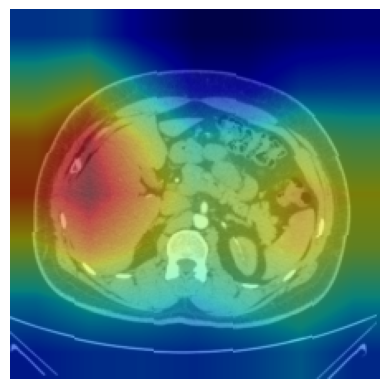

In [108]:
def show_cam_image(img_tensor, attributions_np):
  img = img_tensor.permute(1, 2, 0).cpu().numpy()
  img = (img - img.min()) / (img.max() - img.min())

  plt.imshow(img)
  plt.imshow(attributions_np, cmap='jet', alpha=0.5)
  plt.axis('off')
  plt.show()

show_cam_image(image, attributions_np)

Predicted Class: kidney_tumor


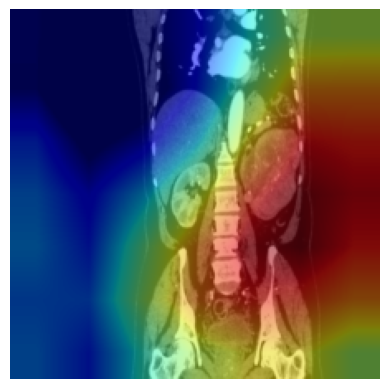

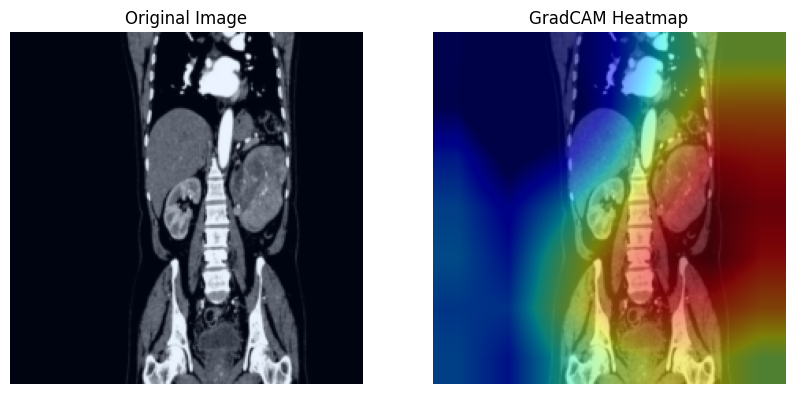

In [113]:
Image_path = "/content/drive/MyDrive/AAIH/Multi Cancer/Kidney Cancer/kidney_tumor/kidney_tumor_0310.jpg"
def predict_withh_Gradcam(image_path):
  img = Image.open(image_path).convert("RGB")
  img = valid_transforms(img).unsqueeze(0).to(device)

  model.eval()

  with torch.no_grad():
    outputs = model(img)
    pred_class = outputs.argmax(dim=1).item()

  class_name = train_dataset.classes[pred_class]
  print("Predicted Class:", class_name)

  target_layer = model.features[-1]
  gradcam = LayerGradCam(model, target_layer)

  attributions = gradcam.attribute(img, pred_class)
  attributions_heatmap = attributions.sum(dim=1, keepdim=True)

  attributions_upsample = torch.nn.functional.interpolate(
      attributions_heatmap,
      size=img.shape[-2:],
      mode='bilinear',
      align_corners=False
  )
  attributions_np = attributions_upsample.squeeze().cpu().detach().numpy()

  # Apply ReLU to attributions (standard for GradCAM) and normalize for visualization
  attributions_np = np.maximum(attributions_np, 0)
  if attributions_np.max() > 0: # Avoid division by zero
      attributions_np = attributions_np / attributions_np.max()

  # Convert the PyTorch tensor 'img' to a NumPy array suitable for matplotlib
  # Remove batch dimension, permute channels to the last, and convert to numpy
  img_for_plot = img.squeeze(0).permute(1, 2, 0).cpu().numpy()
  # Normalize for display, as the 'transform' includes normalization
  img_for_plot = (img_for_plot - img_for_plot.min()) / (img_for_plot.max() - img_for_plot.min())

  #Plot
  plt.imshow(img_for_plot) # Use the correctly prepared image
  plt.imshow(attributions_np, cmap='jet', alpha=0.5)
  plt.axis('off')
  plt.show()

  #Plot side by side
  fig, axs = plt.subplots(1, 2, figsize=(10, 5))
  axs[0].imshow(img_for_plot)
  axs[0].set_title('Original Image')
  axs[0].axis('off')
  axs[1].imshow(img_for_plot)
  axs[1].imshow(attributions_np, cmap='jet', alpha=0.5)
  axs[1].set_title('GradCAM Heatmap')
  axs[1].axis('off')
  plt.show()



predict_withh_Gradcam(Image_path)
